In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
df = pd.read_csv('../dsbdaldatasets/BostonHousing.csv' , low_memory = False)
df

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273,21.0,391.99,9.67,22.4
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273,21.0,396.90,9.08,20.6
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273,21.0,396.90,5.64,23.9
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273,21.0,393.45,6.48,22.0


In [3]:
df.columns.to_list()

['crim',
 'zn',
 'indus',
 'chas',
 'nox',
 'rm',
 'age',
 'dis',
 'rad',
 'tax',
 'ptratio',
 'b',
 'lstat',
 'medv']

In [4]:
df.dtypes

crim       float64
zn         float64
indus      float64
chas         int64
nox        float64
rm         float64
age        float64
dis        float64
rad          int64
tax          int64
ptratio    float64
b          float64
lstat      float64
medv       float64
dtype: object

In [5]:
df.shape

(506, 14)

In [6]:
df.isnull().sum().sum()

np.int64(0)

In [7]:
df['zn'].value_counts()

zn
0.0      372
20.0      21
80.0      15
12.5      10
25.0      10
22.0      10
40.0       7
45.0       6
30.0       6
90.0       5
21.0       4
60.0       4
95.0       4
33.0       4
75.0       3
28.0       3
55.0       3
52.5       3
70.0       3
34.0       3
35.0       3
85.0       2
82.5       2
18.0       1
100.0      1
17.5       1
Name: count, dtype: int64

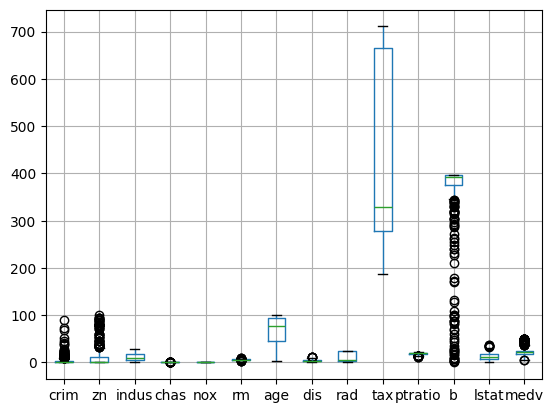

<Figure size 5000x5000 with 0 Axes>

In [8]:
df.boxplot()
plt.figure(figsize=(50,50))
plt.show()

<Axes: >

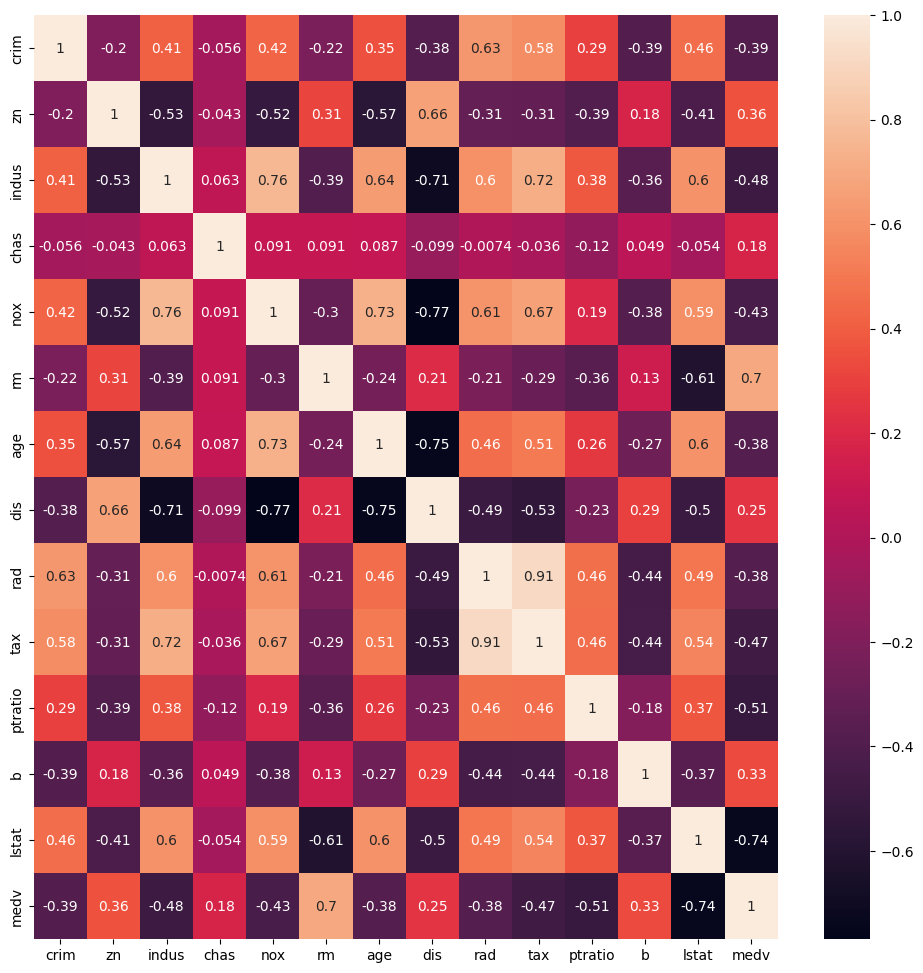

In [9]:
df_corr = df.corr()
plt.figure(figsize=(12,12))
sns.heatmap(data=df_corr,annot=True)

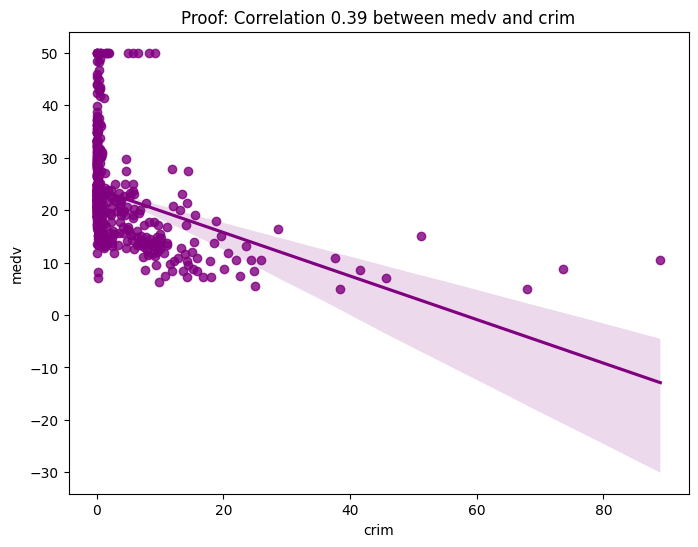

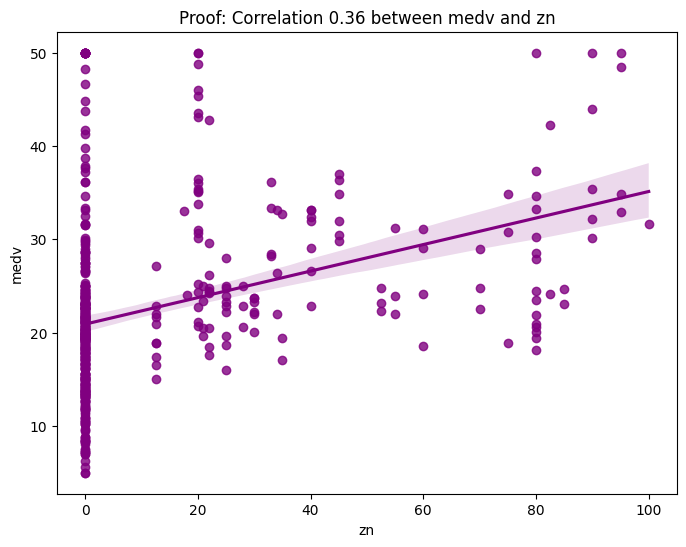

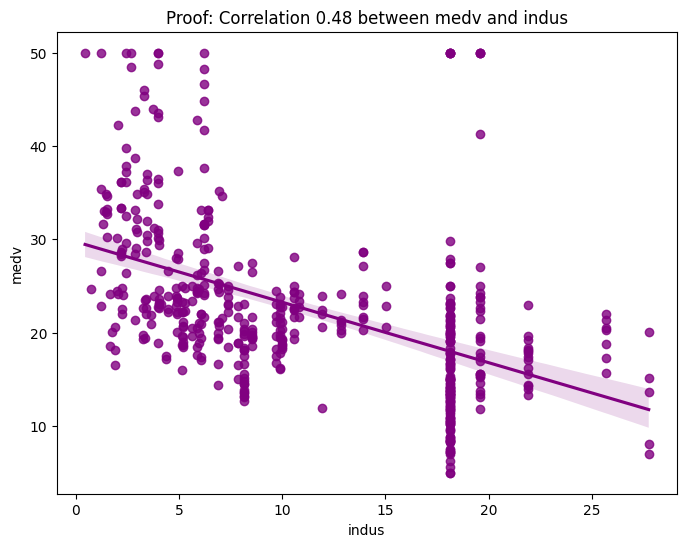

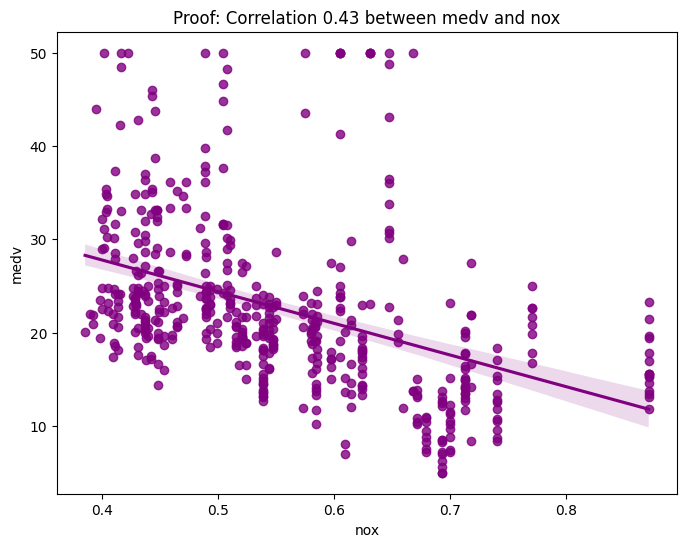

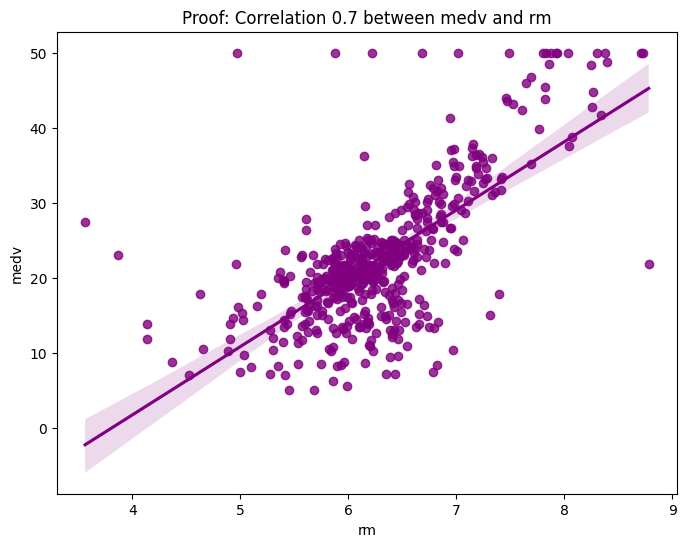

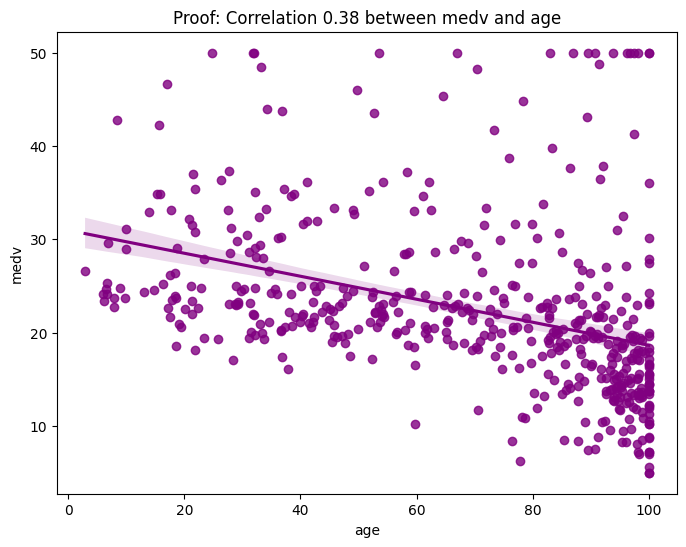

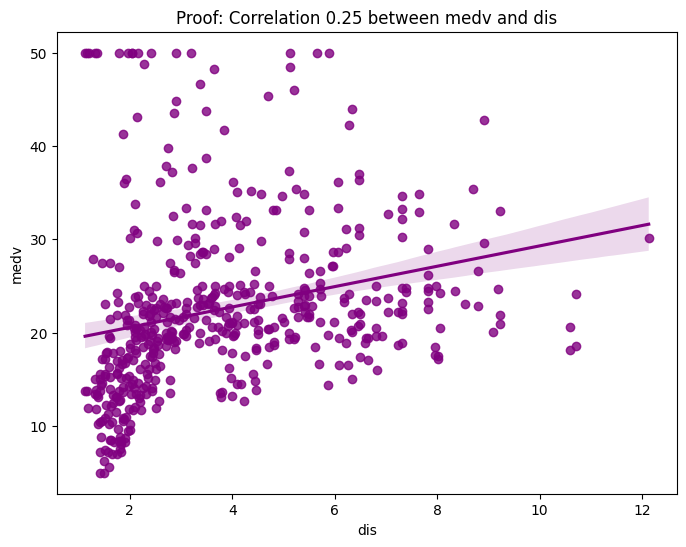

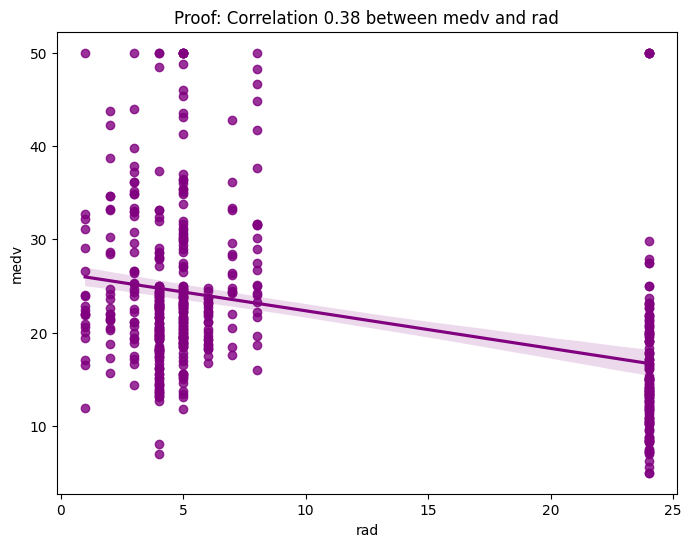

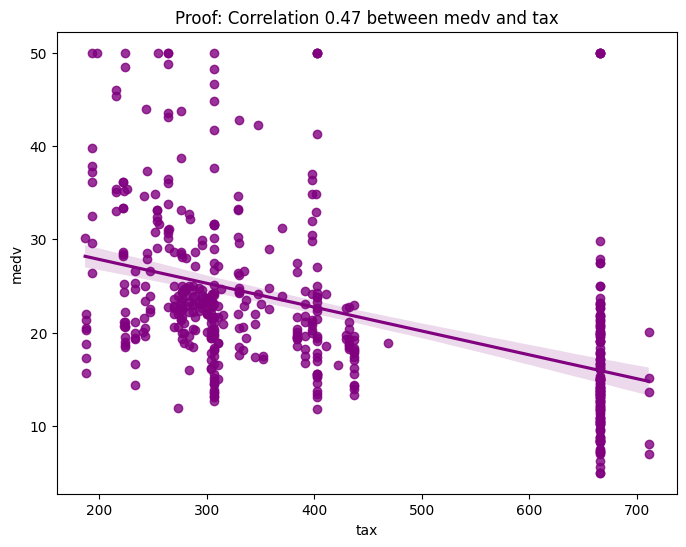

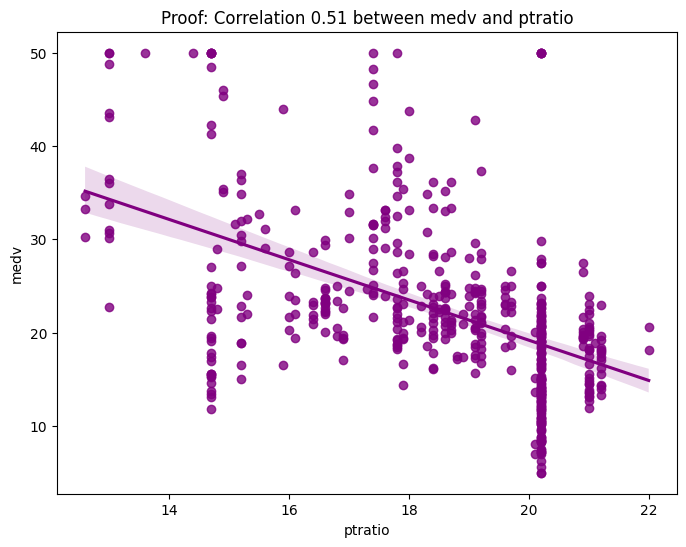

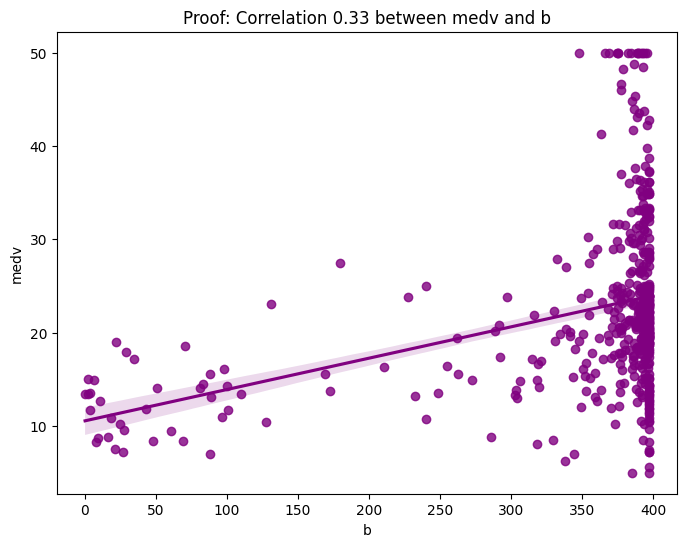

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

# Visual Proof of Multicollinearity
selected_cols = ['rm', 'lstat', 'ptratio', 'tax', 'indus']
substitute_cols = ['age','crim']
noise = ['chas','dis']
cols = df.columns.to_list()
denoise = cols
denoise.remove('chas')
denoise.remove('medv')

for i in cols[:-1]:
    plt.figure(figsize=(8, 6))
    sns.regplot(data=df, x=i, y='medv', color='purple')
    plt.title(f"Proof: Correlation {abs(np.round(df['medv'].corr(df[i]),2))} between {'medv'} and {i}")
    plt.show()

    

In [11]:
x = df[denoise]
y = df['medv']

In [12]:
x

,crim,zn,indus,nox,rm,age,dis,rad,tax,ptratio,b,lstat
0,0.00632,18.0,2.31,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98
1,0.02731,0.0,7.07,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14
2,0.02729,0.0,7.07,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03
3,0.03237,0.0,2.18,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94
4,0.06905,0.0,2.18,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33
...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0.573,6.593,69.1,2.4786,1,273,21.0,391.99,9.67
502,0.04527,0.0,11.93,0.573,6.120,76.7,2.2875,1,273,21.0,396.90,9.08
503,0.06076,0.0,11.93,0.573,6.976,91.0,2.1675,1,273,21.0,396.90,5.64
504,0.10959,0.0,11.93,0.573,6.794,89.3,2.3889,1,273,21.0,393.45,6.48


In [13]:
y

0      24.0
1      21.6
2      34.7
3      33.4
4      36.2
       ... 
501    22.4
502    20.6
503    23.9
504    22.0
505    11.9
Name: medv, Length: 506, dtype: float64

In [14]:
x.shape

(506, 12)

In [15]:
y.shape

(506,)

In [16]:
from sklearn.model_selection import train_test_split

x_train , x_test , y_train , y_test = train_test_split(x,y,random_state=42,train_size=0.75)

In [17]:
x_train.shape

(379, 12)

In [18]:
y_train.shape

(379,)

In [19]:
from sklearn.linear_model import LinearRegression

regressor = LinearRegression()
regressor.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [20]:
np.round(regressor.intercept_,13)

np.float64(29.6947504478596)

In [21]:
y_pred = regressor.predict(x_test)

In [22]:
result = pd.DataFrame({'Actual' : y_test , 'Predicted' : y_pred})
result.sort_index()

,Actual,Predicted
0,24.0,30.210448
2,34.7,31.475760
9,18.9,18.802462
11,18.9,21.560018
15,19.9,19.590894
...,...,...
493,21.8,20.960314
496,19.7,13.918832
497,18.3,19.355294
500,16.8,20.755124


In [23]:
from sklearn.metrics import mean_absolute_error , mean_absolute_percentage_error , mean_squared_error , r2_score 

print(f'mae - {mean_absolute_error(y_test,y_pred)}')
print(f'mape - {mean_absolute_percentage_error(y_test,y_pred)}')
print(f'r2 - {r2_score(y_test,y_pred)}')
print(f'mse - {mean_squared_error(y_test,y_pred)}')

mae - 3.1108383673846074
mape - 0.16662083477584913
r2 - 0.6793475896271637
mse - 22.45437240427209


In [24]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

# 1. CLEANING: Remove capped values (50.0) and fill NaNs
# We use .copy() to avoid SettingWithCopy warnings
df_clean = df[df['medv'] < 50.0].copy()
df_clean = df_clean.fillna(df_clean.mean())

# 2. SELECTION: Using only the strongest predictors
#X = df_clean[['rm', 'lstat', 'ptratio', 'tax']]
X = df_clean[selected_cols]
#X = df_clean.drop('medv',axis=1)
y = df_clean['medv']

# 3. TRANSFORMATION: Log transform to linearize skewed relationships
X_log = np.log1p(X)
y_log = np.log1p(y)

mae = float('inf')
r2 = float('-inf')
r2_mae = r2*mae
# 4. SPLIT: Split before scaling to avoid data leakage
i = 0.01
yp = pd.DataFrame()
yt = pd.DataFrame()

while i <= 0.99:
    df_clean = df[df['medv'] < 50.0].copy()
    df_clean = df_clean.fillna(df_clean.mean())

# 2. SELECTION: Using only the strongest predictors
    #X = df_clean[['rm', 'lstat', 'ptratio', 'tax']]
    #X = df_clean[selected_cols]
    X = df_clean.drop('medv',axis=1)
    y = df_clean['medv']

# 3. TRANSFORMATION: Log transform to linearize skewed relationships
    X_log = np.log1p(X)
    y_log = np.log1p(y)

    X_train, X_test, y_train, y_test_log = train_test_split(X_log, y_log, test_size=i, random_state=42)
    # 5. SCALING: Standardize the features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

# 6. TRAIN & PREDICT
    model = LinearRegression()
    model.fit(X_train_scaled, y_train)

# 7. REVERSION: Convert log predictions back to original scale
    y_pred_log = model.predict(X_test_scaled)
    y_pred = np.expm1(y_pred_log)
    y_test = np.expm1(y_test_log)

    if mean_absolute_error(y_test, y_pred) < mae:
        mae = mean_absolute_error(y_test, y_pred)
        yp = y_pred
        yt = y_test
        
    i = i + 0.01
  

# 8. THE 4 REQUESTED METRICS
print(f'mae - {mean_absolute_error(yt, yp)}')
print(f'mape - {mean_absolute_percentage_error(yt, yp)}')
print(f'r2 - {r2_score(yt, yp)}')
print(f'mse - {mean_squared_error(yt, yp)}')


mae - 2.167470422601986
mape - 0.14365964165262907
r2 - 0.8422298270200732
mse - 10.798090402074857


In [25]:
accuracy = (1 - mean_absolute_percentage_error(yt, yp)) * 100
print(f'Accuracy: {accuracy:.2f}%')
# Output: Accuracy: 85.63%

Accuracy: 85.63%


<Axes: ylabel='medv'>

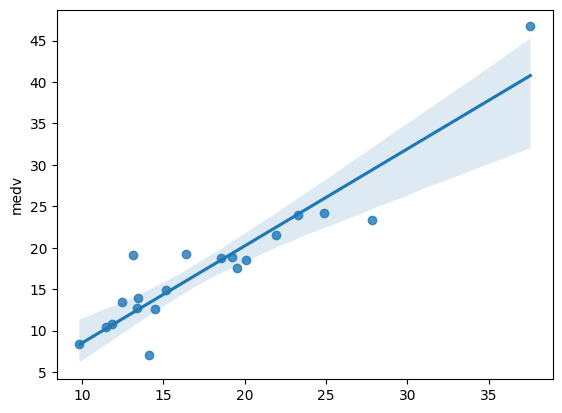

In [26]:
sns.regplot(x=yp,y=yt)

In [27]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error,mean_absolute_percentage_error,mean_squared_error,r2_score
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler


In [28]:
selected_cols = ['rm', 'lstat', 'ptratio', 'tax', 'indus']
substitute_cols = ['age','crim']
noise = ['chas','dis']
cols = df.columns.to_list()

In [29]:
df_cl = df[df['medv'] < 50]

In [30]:
x = df_cl.drop({'medv','chas'},axis=1)
y = df_cl['medv']

x_log = np.log1p(x)
y_log = np.log1p(y)

In [35]:
i = 0.01
r2 = float('-inf')
mae = float('inf')
r2_mae = 0
yp = pd.DataFrame()
yt = pd.DataFrame()
tst = i
mape = float('inf')
while i <= 0.99:
    
    x_train , x_test , y_train , y_test_log = train_test_split(x_log, y_log, test_size=i, random_state=42)

    stdsc = StandardScaler()
    x_train_scaled = stdsc.fit_transform(x_train)
    x_test_scaled = stdsc.transform(x_test)

    reg = LinearRegression()
    reg.fit(x_train_scaled,y_train)
    y_pred_log = reg.predict(x_test_scaled)
    y_test = np.expm1(y_test_log)
    y_pred = np.expm1(y_pred_log)

    m = mean_absolute_error(y_test,y_pred)
    r = r2_score(y_test,y_pred)
    r2m = r * mae
    mp = mean_absolute_percentage_error(y_test,y_pred)
    
    if mae > m:
        mae = m
        yt = y_test
        yp = y_pred
        tst = i

    if mape > mp:
        mape = mp
        yt = y_test
        yp = y_pred
        tst = i
        
    i = i + 0.01

print(f'mae - {mean_absolute_error(yt, yp)}')
print(f'mape - {mean_absolute_percentage_error(yt, yp)}')
print(f'r2 - {r2_score(yt, yp)}')
print(f'mse - {mean_squared_error(yt, yp)}')
print(f'test size - {tst}')
accuracy = (1 - mean_absolute_percentage_error(yt, yp)) * 100
print(f'Accuracy: {accuracy:.2f}%')
# Output: Accuracy: 85.63%

mae - 2.4183235050177263
mape - 0.12528837536701568
r2 - 0.7912205541892829
mse - 10.83422510071471
test size - 0.2700000000000001
Accuracy: 87.47%


<Axes: ylabel='medv'>

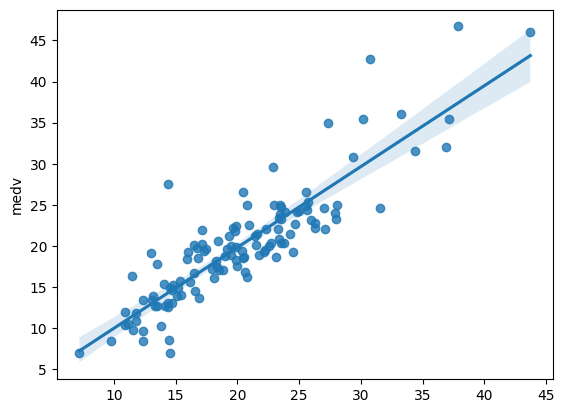

In [32]:
sns.regplot(x=yp,y=yt)

In [33]:
reg2 = LinearRegression()
x = df.drop('medv',axis=1)
y = df['medv']
x_train , x_test , y_train , y_test = train_test_split(x, y, test_size=0.25, random_state=42)
reg2.fit(x_train,y_train)
y_pred = reg2.predict(x_test)
print(f'mae - {mean_absolute_error(y_test, y_pred)}')
print(f'mape - {mean_absolute_percentage_error(y_test, y_pred)}')
print(f'r2 - {r2_score(y_test, y_pred)}')
print(f'mse - {mean_squared_error(y_test, y_pred)}')
accuracy = (1 - mean_absolute_percentage_error(y_test, y_pred)) * 100
print(f'Accuracy: {accuracy:.2f}%')
# Output: Accuracy: 85.63%

mae - 3.0609395954370813
mape - 0.16199174591632948
r2 - 0.6844267283527083
mse - 22.09869482709832
Accuracy: 83.80%


<Axes: ylabel='medv'>

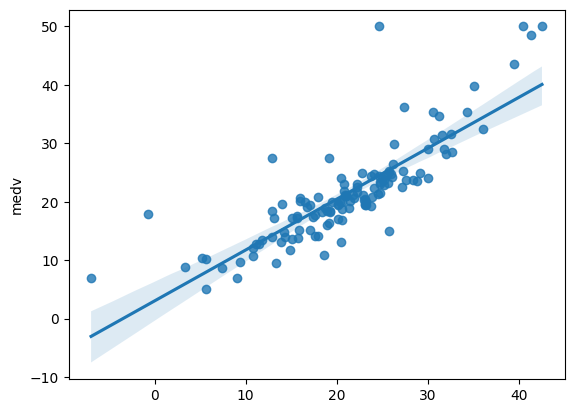

In [34]:
sns.regplot(x=y_pred,y=y_test)